# Reducción de dimensiones con PCA y Clustering

In [3]:
# Cargar librerias para ciencia de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Preprocesamiento de los datos
from sklearn.preprocessing import StandardScaler # Normalización
from sklearn.preprocessing import LabelEncoder #


# PCA y Clustering
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


# Visualización de componentes principales
from yellowbrick.features import PCA as biplot

# Visualización de clusters
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

pd.set_option('display.max_columns', None)

In [4]:
# Para conectarse con google drive
from google.colab import drive
drive.mount('/gdrive')

# Configurar directorio de trabajo
os.chdir('/gdrive/MyDrive/Colab Notebooks/Ciencia de Datos con Python')

Mounted at /gdrive


# Caso 1. Arrestos en Estados Unidos

Este conjunto de datos contiene estadísticas en arrestos por cada 100.000 residentes por agresión, asesinato y violación en cada uno de los 50 estados de EE. UU. en 1973. También se proporciona el porcentaje de la población que vive en áreas urbanas.

- Asesinato: Arrestos por asesinato (por cada 100.000 habitantes)
- Agresión: Detenciones por agresión (por cada 100.000 habitantes)
- Violación: Detenciones por violación (por cada 100.000 habitantes)
- Población: Porcentaje de población urbana

In [5]:
datos = pd.read_csv("USArrestos.csv")
datos

,Estado,Asesinato,Agresión,Violación,Población
0,Alabama,13.2,236,21.2,58
1,Alaska,10.0,263,44.5,48
2,Arizona,8.1,294,31.0,80
3,Arkansas,8.8,190,19.5,50
4,California,9.0,276,40.6,91
5,Colorado,7.9,204,38.7,78
6,Connecticut,3.3,110,11.1,77
7,Delaware,5.9,238,15.8,72
8,Florida,15.4,335,31.9,80
9,Georgia,17.4,211,25.8,60


## Análisis Exploratorio

In [6]:
# Estadísticas descriptivas
datos.describe().round(2)

,Asesinato,Agresión,Violación,Población
count,50.00,50.00,50.00,50.00
mean,7.79,170.76,21.23,65.54
std,4.36,83.34,9.37,14.47
min,0.80,45.00,7.30,32.00
25%,4.08,109.00,15.08,54.50
50%,7.25,159.00,20.10,66.00
75%,11.25,249.00,26.18,77.75
max,17.40,337.00,46.00,91.00


<Figure size 600x600 with 0 Axes>

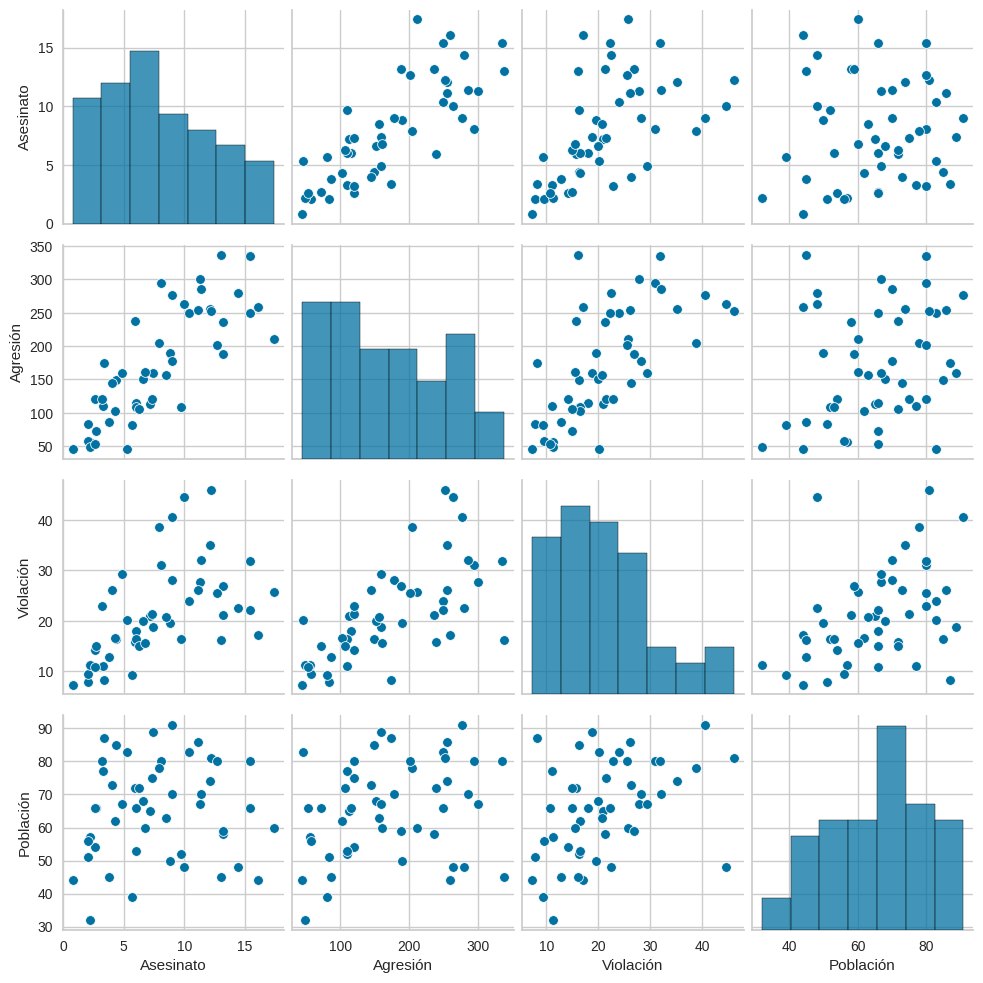

In [7]:
# Relación entre variables
plt.figure(figsize=(6,6))
sns.pairplot(data=datos)
plt.show()

In [8]:
# Correlación
datos.corr(numeric_only=True)

,Asesinato,Agresión,Violación,Población
Asesinato,1.000000,0.801873,0.563579,0.069573
Agresión,0.801873,1.000000,0.665241,0.258872
Violación,0.563579,0.665241,1.000000,0.411341
Población,0.069573,0.258872,0.411341,1.000000


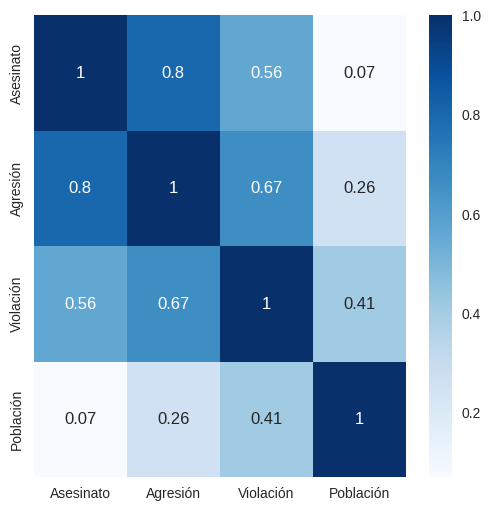

In [9]:
# Heatmap con la matriz de correlación
plt.figure(figsize=(6,6))
sns.heatmap(datos.corr(numeric_only=True), annot=True, cmap='Blues')
plt.show()

## Componentes Principales

In [10]:
# Extraer las variables númericas
X = datos.drop(columns=['Estado']).copy()

### Normalización

La normalización de X se realiza con la siguiente ecuación:

$$
X^{scaled}_{i} = \frac{X_i-\mu_X}{\sigma_{X}}
$$

In [11]:
# Estandarizar los datos de entrada X
scale_x = StandardScaler(with_std=True, with_mean=True)
scale_x.fit(X)
X_scale = scale_x.transform(X)
X_scale

array([[ 1.25517927,  0.79078716, -0.00345116, -0.52619514],
       [ 0.51301858,  1.11805959,  2.50942392, -1.22406668],
       [ 0.07236067,  1.49381682,  1.05346626,  1.00912225],
       [ 0.23470832,  0.23321191, -0.18679398, -1.08449238],
       [ 0.28109336,  1.2756352 ,  2.08881393,  1.77678094],
       [ 0.02597562,  0.40290872,  1.88390137,  0.86954794],
       [-1.04088037, -0.73648418, -1.09272319,  0.79976079],
       [-0.43787481,  0.81502956, -0.58583422,  0.45082502],
       [ 1.76541475,  1.99078607,  1.1505301 ,  1.00912225],
       [ 2.22926518,  0.48775713,  0.49265293, -0.38662083],
       [-0.57702994, -1.51224105, -0.11129987,  1.21848371],
       [-1.20322802, -0.61527217, -0.75839217, -0.80534376],
       [ 0.60578867,  0.94836277,  0.29852525,  1.21848371],
       [-0.13637203, -0.70012057, -0.0250209 , -0.03768506],
       [-1.29599811, -1.39102904, -1.07115345, -0.5959823 ],
       [-0.41468229, -0.67587817, -0.34856705,  0.03210209],
       [ 0.44344101, -0.

### Componentes principales

In [12]:
# Componentes Principales
pca_model = PCA()
pca_model.fit(X_scale)

PCA()

In [13]:
# Porcentaje de varianza explicada
pca_model.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

In [14]:
# ¿Qué porccentaje de varianza explican los dos primeros componentes?
var_explicada = pca_model.explained_variance_ratio_.cumsum()
var_explicada

array([0.62006039, 0.86750168, 0.95664248, 1.        ])

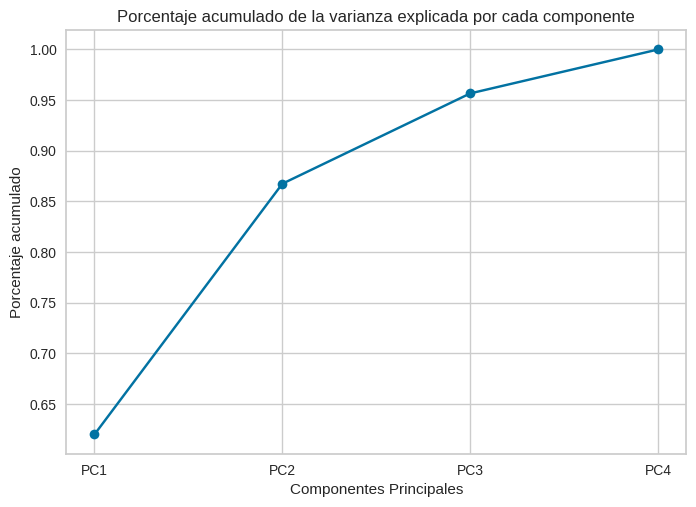

In [15]:
# Gráfico del porcentaje de varianza acumulada
plt.plot(["PC"+str(i+1) for i in range(pca_model.n_components_)], var_explicada, marker='o')
plt.title("Porcentaje acumulado de la varianza explicada por cada componente")
plt.xlabel("Componentes Principales")
plt.ylabel("Porcentaje acumulado")
plt.show()

In [16]:
# Pesos de las variables en cada componente
componentes = pd.DataFrame(pca_model.components_)
componentes.columns = X.columns
componentes.index = ["PC"+str(i+1) for i in range(pca_model.n_components_)]
componentes

,Asesinato,Agresión,Violación,Población
PC1,0.535899,0.583184,0.543432,0.278191
PC2,-0.418181,-0.187986,0.167319,0.872806
PC3,-0.341233,-0.268148,0.817778,-0.378016
PC4,-0.649228,0.743407,-0.089024,-0.133878


In [17]:
# Transformación de los datos originales
Z = pca_model.transform(X_scale)
Z = pd.DataFrame(Z)
Z.columns = ["PC"+str(i+1) for i in range(pca_model.n_components_)]
Z['Estado'] = datos['Estado']
Z

,PC1,PC2,PC3,PC4,Estado
0,0.985566,-1.133392,-0.444269,-0.156267,Alabama
1,1.950138,-1.073213,2.040003,0.438583,Alaska
2,1.763164,0.745957,0.054781,0.834653,Arizona
3,-0.141420,-1.119797,0.114574,0.182811,Arkansas
4,2.523980,1.542934,0.598557,0.341996,California
5,1.514563,0.987555,1.095007,-0.001465,Colorado
6,-1.358647,1.088928,-0.643258,0.118469,Connecticut
7,0.047709,0.325359,-0.718633,0.881978,Delaware
8,3.013042,-0.039229,-0.576829,0.096285,Florida
9,1.639283,-1.278942,-0.342460,-1.076797,Georgia


### Biplot

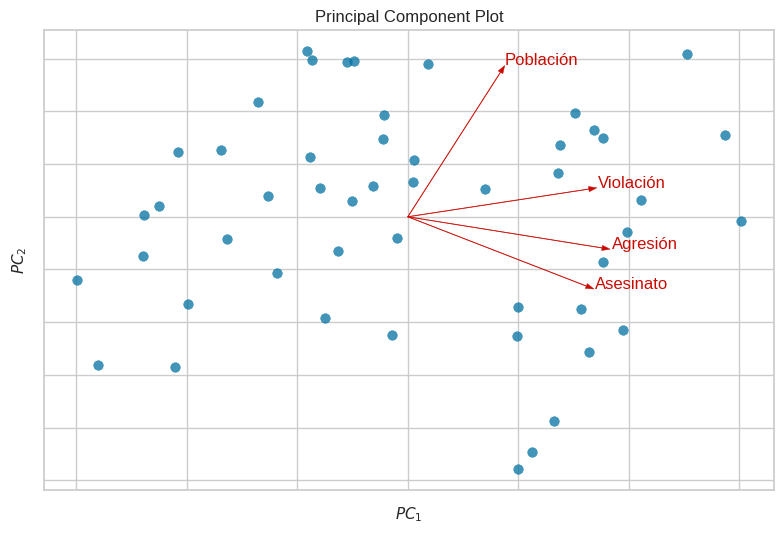

<Axes: title={'center': 'Principal Component Plot'}, xlabel='$PC_1$', ylabel='$PC_2$'>

In [18]:
# Biplot con etiquetas de estados
visualizer = biplot(scale=True, proj_features=True)
visualizer.fit_transform(X)
visualizer.show()

## Análisis de cluster

### Determinar el número de cluster

El KElbowVisualizer implementa el método "codo" para ayudar a seleccionar la cantidad óptima de clústeres ajustando el modelo con un rango de valores para el número de cluster.



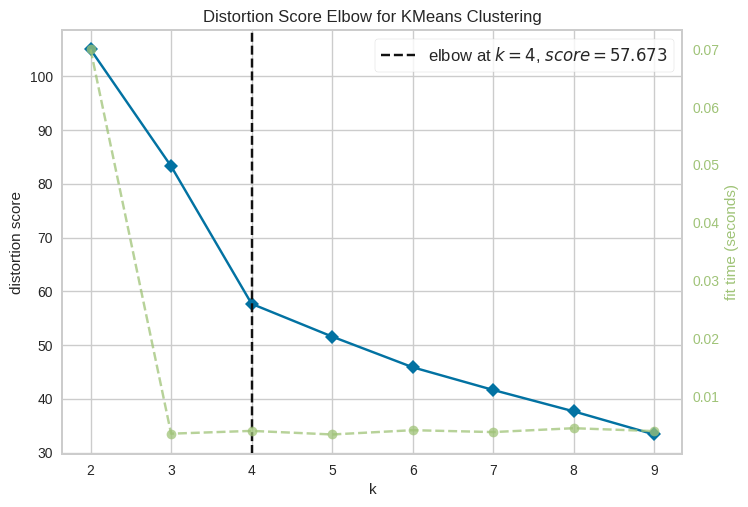

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Determinar el numero de cluster
n_cluster_vis = KElbowVisualizer(KMeans(n_init='auto', random_state=42), k=(2,10))
n_cluster_vis.fit(X_scale)
n_cluster_vis.show()

### Gráfico de Silueta


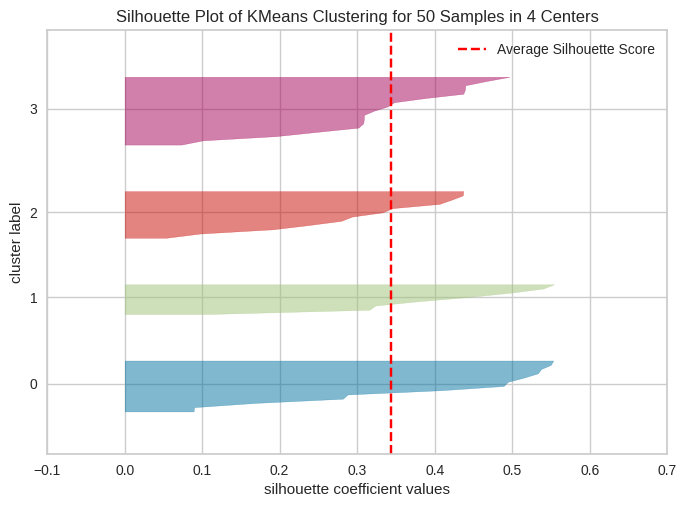

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 50 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [20]:
# Gráfico de silueta
silueta_vis = SilhouetteVisualizer(KMeans(4, n_init='auto', random_state=42), colors='yellowbrick')
silueta_vis.fit(X_scale)
silueta_vis.show()

### Clusters con Kmeans

In [21]:
cluster_model = KMeans(4, n_init='auto', random_state=42)
cluster_model.fit(X_scale)

KMeans(n_clusters=4, random_state=42)

In [22]:
# Asignar el cluster
datos['Cluster'] = cluster_model.predict(X_scale)
datos

,Estado,Asesinato,Agresión,Violación,Población,Cluster
0,Alabama,13.2,236,21.2,58,1
1,Alaska,10.0,263,44.5,48,2
2,Arizona,8.1,294,31.0,80,2
3,Arkansas,8.8,190,19.5,50,1
4,California,9.0,276,40.6,91,2
5,Colorado,7.9,204,38.7,78,2
6,Connecticut,3.3,110,11.1,77,3
7,Delaware,5.9,238,15.8,72,3
8,Florida,15.4,335,31.9,80,2
9,Georgia,17.4,211,25.8,60,1


### Análisis Exploratorios con Cluster

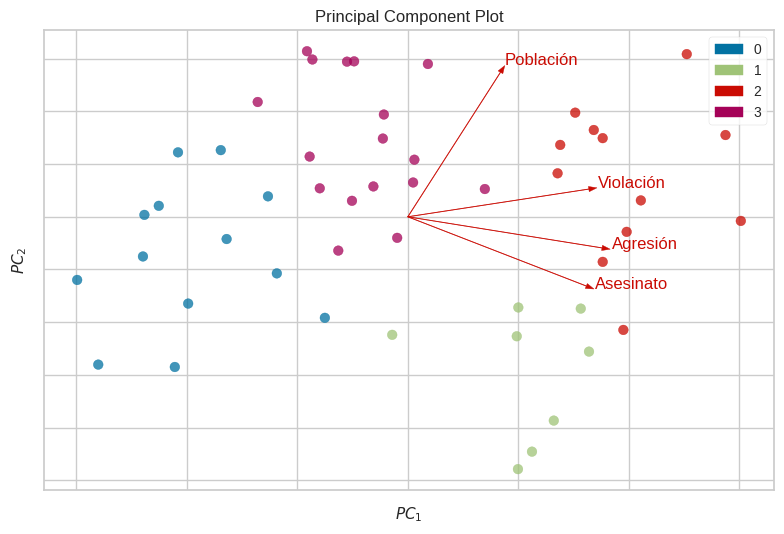

<Axes: title={'center': 'Principal Component Plot'}, xlabel='$PC_1$', ylabel='$PC_2$'>

In [23]:
# Biplot y cluster
cluster_encoder = LabelEncoder().fit(datos['Cluster'])
y = cluster_encoder.transform(datos['Cluster'])
visualizer = biplot(scale=True, proj_features=True)
visualizer.fit_transform(X, y)
visualizer.show()

In [24]:
# Estadísticas por cluster
datos.groupby('Cluster').mean(numeric_only=True)

,Asesinato,Agresión,Violación,Población
Cluster,,,,
0,3.600000,78.538462,12.176923,52.076923
1,13.937500,243.625000,21.412500,53.750000
2,10.966667,264.000000,33.608333,76.500000
3,5.852941,141.176471,19.335294,73.647059


<Axes: xlabel='Cluster', ylabel='Agresión'>

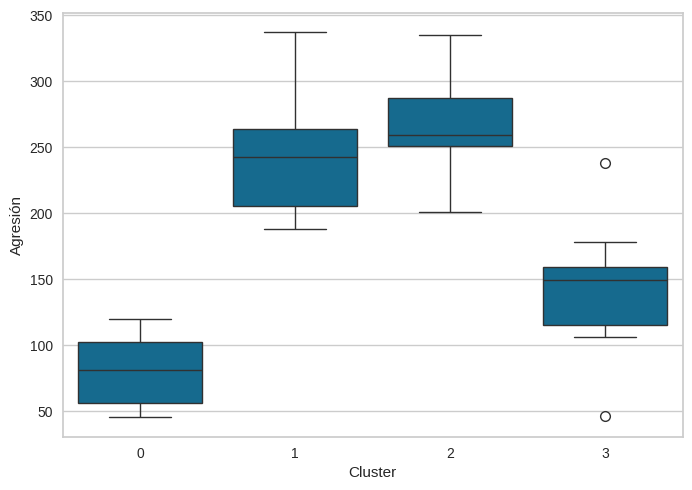

In [25]:
# Boxplot por cluster
sns.boxplot(data=datos, x='Cluster', y='Agresión')

<Axes: xlabel='Asesinato', ylabel='Población'>

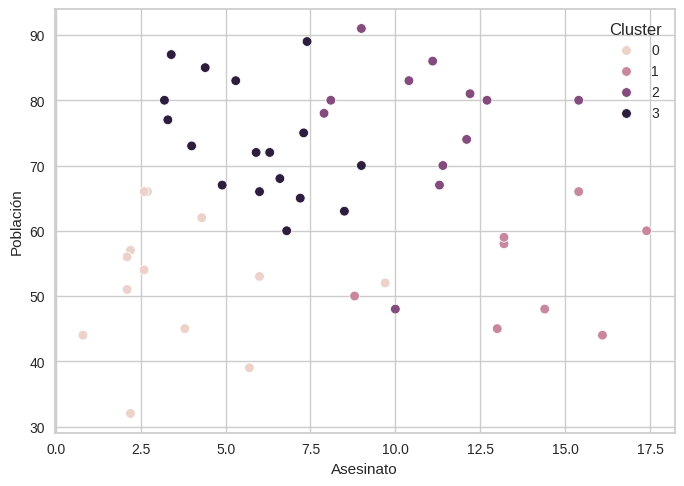

In [26]:
# Gráficos de dispersión
sns.scatterplot(data=datos, x='Asesinato', y='Población', hue='Cluster')

In [27]:
# Estados con mayor nivel de arrestos se encuentran en los cluster 1 y 2
Z['Cluster'] = cluster_model.predict(X_scale)
Z.loc[Z['Cluster'].isin([1,2]),['PC1','Estado','Cluster']]

,PC1,Estado,Cluster
0,0.985566,Alabama,1
1,1.950138,Alaska,2
2,1.763164,Arizona,2
3,-0.141420,Arkansas,1
4,2.523980,California,2
5,1.514563,Colorado,2
8,3.013042,Florida,2
9,1.639283,Georgia,1
12,1.378911,Illinois,2
17,1.564818,Louisiana,1


In [28]:
# Estados con mayor nivel de criminalidad
Z.sort_values(by='PC1', ascending=False).head(5)

,PC1,PC2,PC3,PC4,Estado,Cluster
8,3.013042,-0.039229,-0.576829,0.096285,Florida,2
27,2.874395,0.775600,1.163380,-0.314515,Nevada,2
4,2.523980,1.542934,0.598557,0.341996,California,2
21,2.108441,0.155397,0.384869,-0.102372,Michigan,2
30,1.980024,-0.142849,0.183692,0.339534,New Mexico,2


<Axes: ylabel='Estado'>

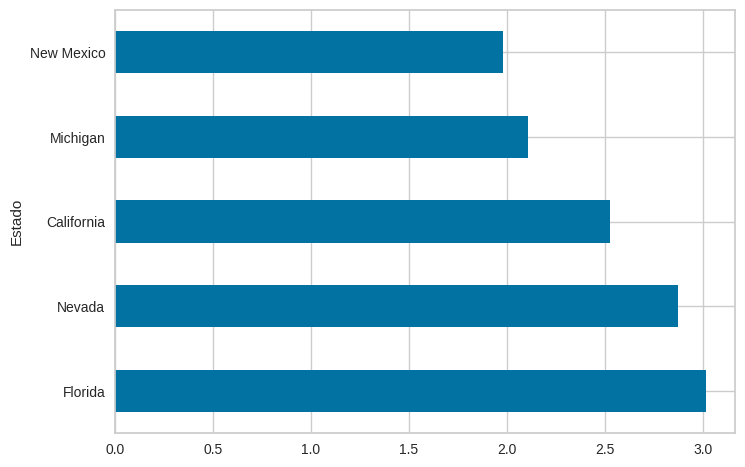

In [29]:
# Estados con mayor nivel de criminalidad
Z.sort_values(by='PC1', ascending=False).head(5).set_index('Estado')['PC1'].plot.barh()

In [30]:
# Estados con menor nivel de arrestos se encuentran en los cluster 0 y 3
Z.loc[Z['Cluster'].isin([0,3]),['PC1','Estado','Cluster']]

,PC1,Estado,Cluster
6,-1.358647,Connecticut,3
7,0.047709,Delaware,3
10,-0.912657,Hawaii,3
11,-1.639800,Idaho,0
13,-0.505461,Indiana,3
14,-2.253646,Iowa,0
15,-0.796881,Kansas,3
16,-0.750859,Kentucky,0
18,-2.396829,Maine,0
20,-0.486166,Massachusetts,3


# Caso 2. Compras de Clientes mayoristas

**Contexto**: El conjunto de datos se refiere a clientes de un distribuidor mayorista. Incluye el gasto anual en unidades monetarias (u.m.) en diversas categorías de productos:

1. Fresh: gasto anual en productos frescos
2. Milk: gasto anual en productos lácteos
3. Grocery: gasto anual en productos de abarrotes
4. Frozen: gasto anual en productos congelados
5. Detergents_Paper: gasto anual en detergentes y productos de papel
6. Delicatessen: gasto anual en productos y charcutería

Además, se tiene información sobre:
- Channel: Canal de clientes - (1) Horeca (Hotel/Restaurante/Cafetería) o (2) Canal Retail
- Region: Región del cliente

**Objetivo**:
- Hacer un análisis de componentes principales para identificar si los productos se pueden agrupar en categorías dependiendo de su correlación en el nivel de las compras.
- Hacer un análisis de cluster para identificar grupos de clientes según el nivel de compras de diferentes productos.

In [31]:
# Cargar datos
compras = pd.read_csv('wholesale_customers_data.csv')
compras

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


In [32]:
# Extraer las variables númericas


In [33]:
# Análisis de correlación


In [34]:
# Pairplot


In [35]:
# Estandarizar los datos de entrada X


### Componentes principales

In [36]:
# Componentes Principales


In [37]:
# Porcentaje de varianza explicada


In [38]:
# ¿Qué porccentaje de varianza explican los dos primeros componentes?


In [39]:
# Gráfico del porcentaje de varianza acumulada


In [40]:
# Pesos de las variables en cada componente


**¿Cómo interpretaría los tres primeros componentes en relación a las variables originales?**

Conclusion:

In [41]:
# Transformación de los datos originales


# Agregue las columnas categóricas


In [42]:
# Gráfique los componentes principales


In [43]:
# Biplot


### Análisis de cluster

In [44]:
# Determinar el numero de cluster


In [45]:
# Gráfico de silueta


### Clusters con Kmeans

In [46]:
# Kmeans

In [47]:
# Biplot con cluster


In [48]:
# Compare las estadísticas de los cluster


In [49]:
# Gráfique las variables por cluster
